This question involves the use of multiple linear regression on the `Auto` data set.

**Part (a)**\
Produce a scatterplot matrix which includes all of the variables in the data set.

In [23]:
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
Auto = load_data('Auto')
Auto.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


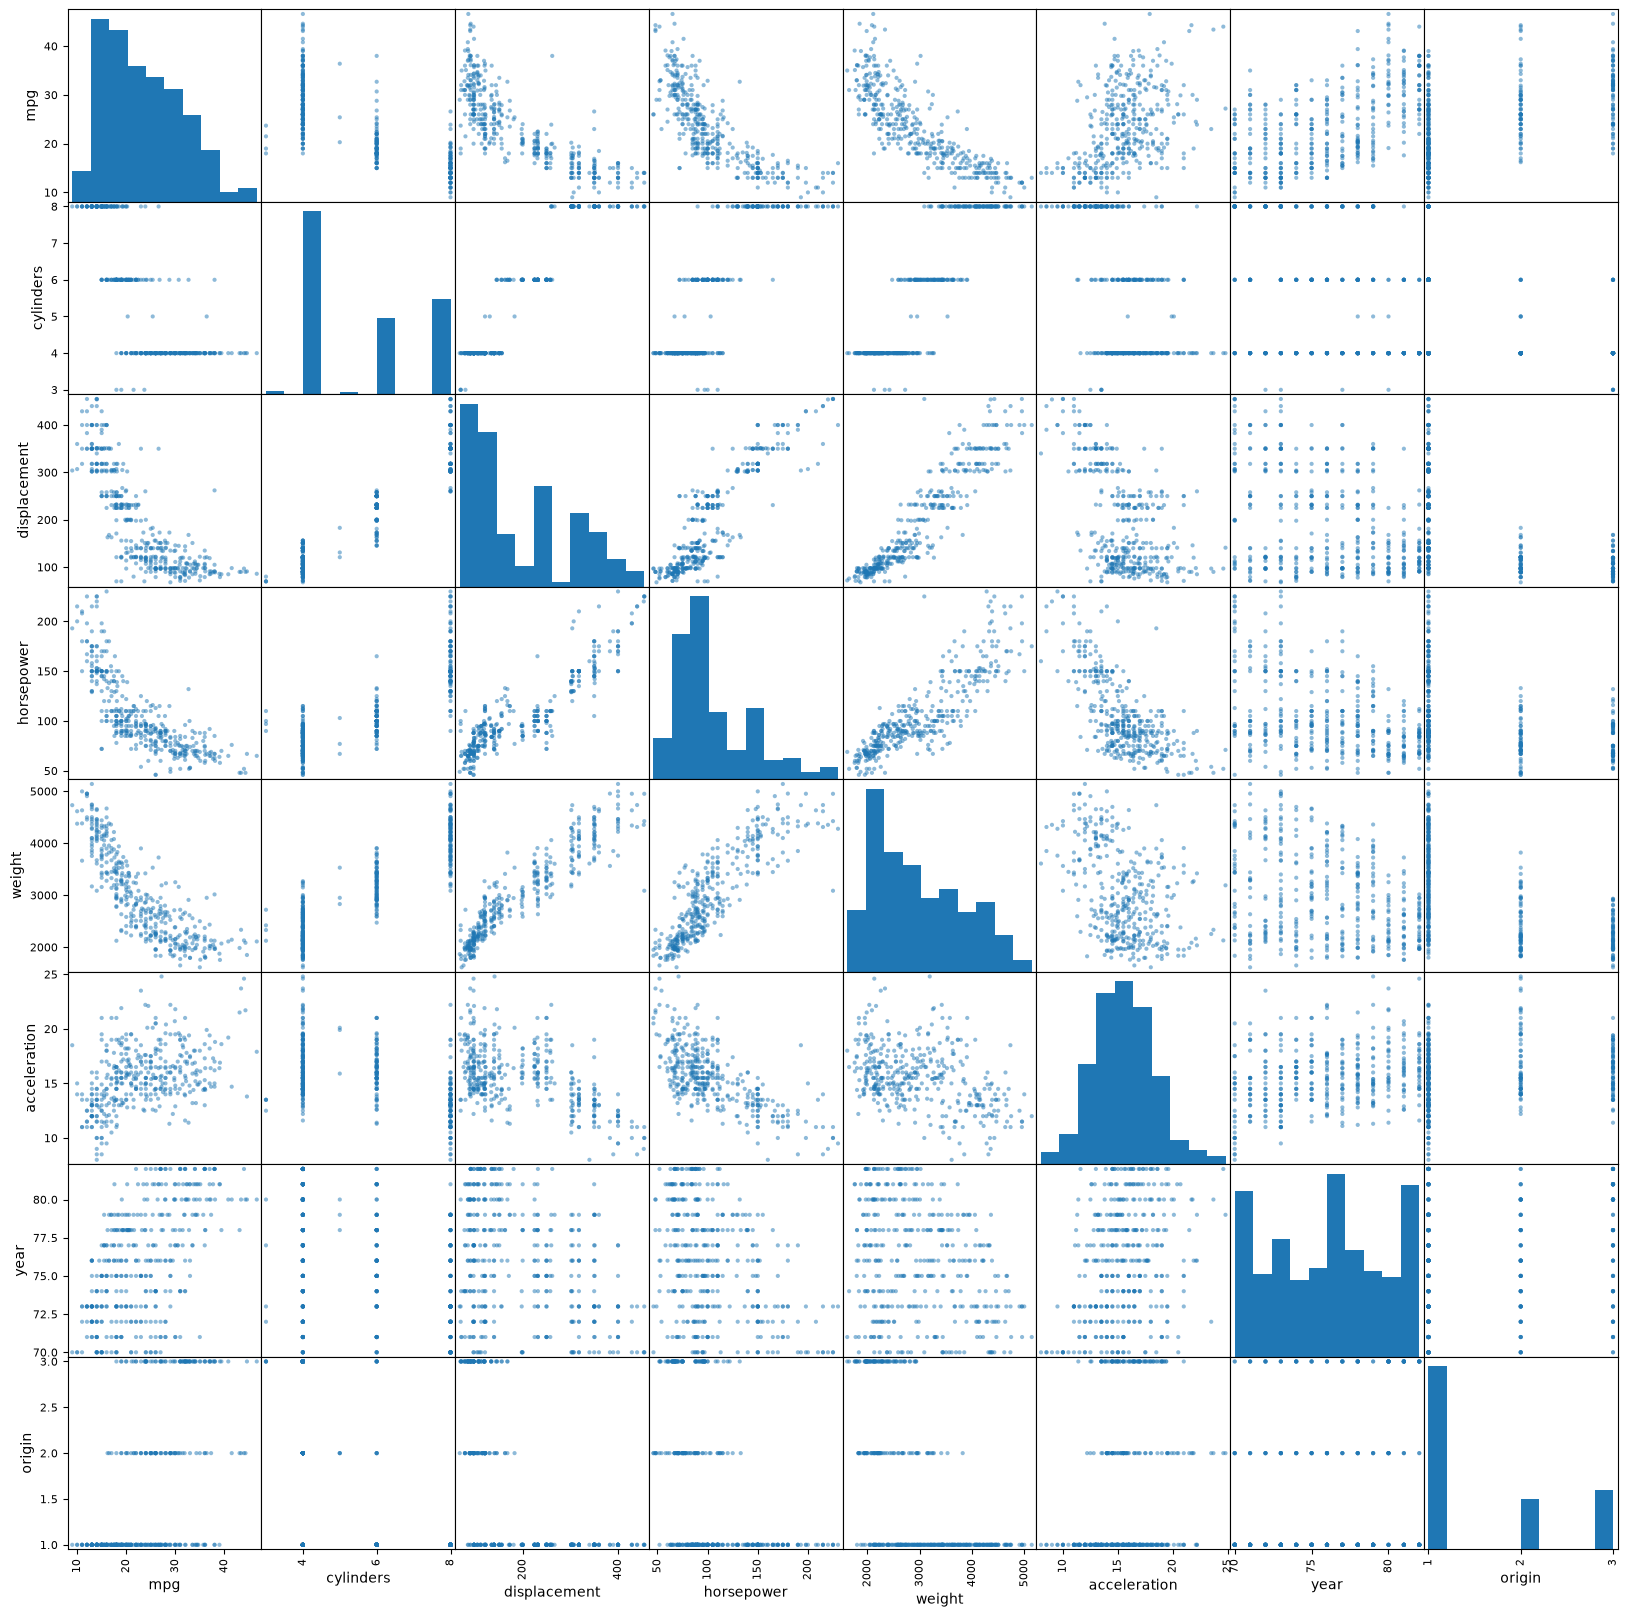

In [25]:
pd.plotting.scatter_matrix(Auto, figsize=(20,20));

**Part (b)**\
Compute the matrix of correlations between the variables using the `DataFrame.corr()` method.

In [26]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


**Part (c)**\
Use the `sm.OLS()` function to perform a multiple linear regression with `mpg` as the response and all other variables except `name` as predictors. Use the `summarize()` function to print the results.

In [92]:
X = Auto[Auto.columns.drop(['mpg'])].copy()
X['constant'] = 1
y = Auto['mpg']

linear_model = sm.OLS(y, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          2.04e-139
Time:                        23:59:33   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
cylinders       -0.4934      0.323     -1.526   

**Part (d)**\
Produce some of diagnostic plots of the linear regression fit as described in the lab.

In [93]:
import math

def diagnostic_plots(model):
    fitted_values = model.fittedvalues
    variance = model.scale
    residuals = model.resid
    leverage = model.get_influence().hat_matrix_diag

    residuals_sorted = residuals.sort_values(ascending=True)

    N = len(residuals_sorted)
    quantiles = [math.erf((i+0.5)/N) for i in range(0,N)]

    residuals_studentised = residuals / ((1-leverage) * variance) ** 0.5
    residuals_sqrt = abs(residuals_studentised) ** 0.5

    diagnostic = plt.Figure(figsize=(12,12))
    axs = diagnostic.subplots(nrows=2, ncols=2)

    axs[0][0].scatter(fitted_values, residuals, s=4)
    axs[0][0].axhline(0)
    axs[0][0].set_xlabel('Fitted Values')
    axs[0][0].set_ylabel('Residuals')
    axs[0][0].set_title('Residuals against fitted values')

    axs[0][1].scatter(residuals_sorted, quantiles, s=4)
    axs[0][1].set_xlabel('Sorted residuals')
    axs[0][1].set_ylabel('Quantiles')
    axs[0][1].set_title('Normal Q-Q')

    axs[1][0].scatter(fitted_values, residuals_sqrt, s=4)
    axs[1][0].set_xlabel('Fitted Values')
    axs[1][0].set_ylabel('Square root of |studentised residuals|')
    axs[1][0].set_title('Scale against location')

    axs[1][1].scatter(leverage, residuals_studentised, s=4)
    axs[1][1].set_xlabel('Leverage')
    axs[1][1].set_ylabel('Studentised residuals')
    axs[1][1].set_title('Studentised residuals against leverage')

    return diagnostic    

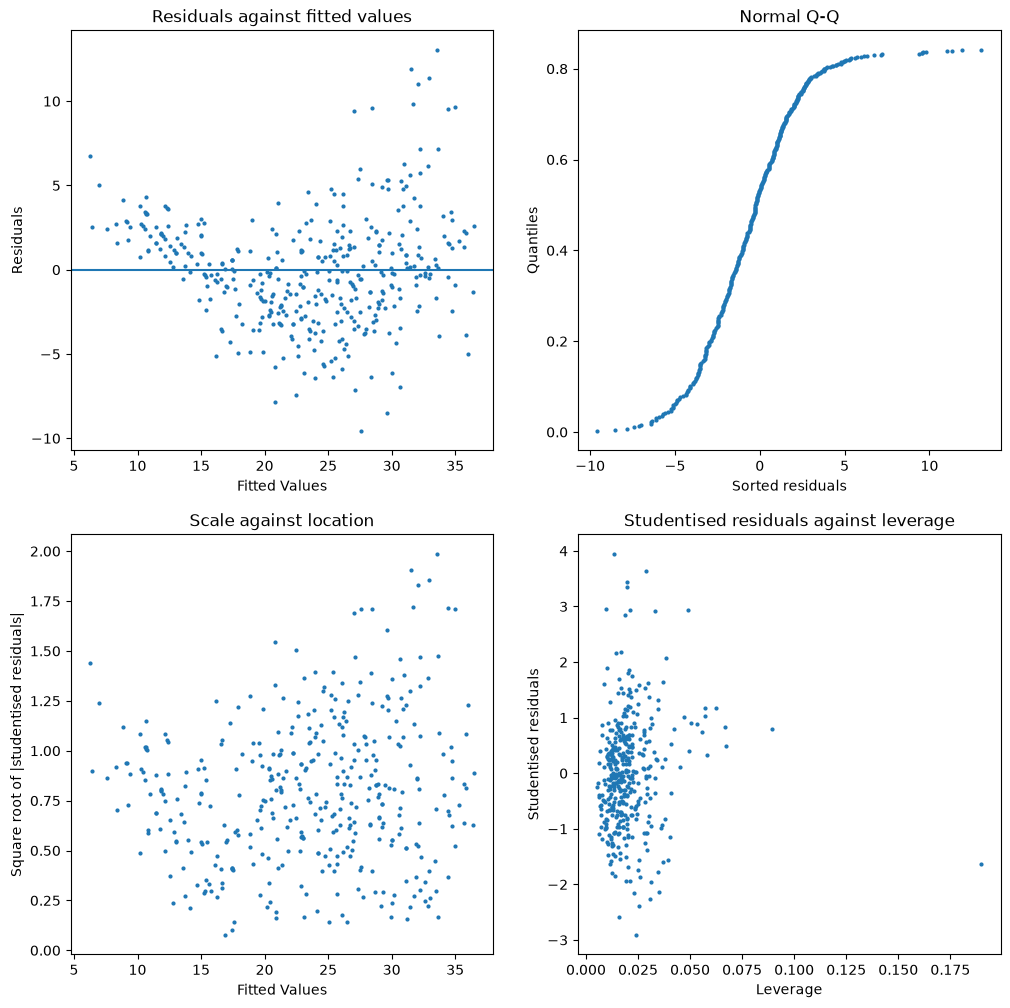

In [94]:
diagnostic_plots(linear_model)

**Part (e)**\
Fit some models with interactions as described in the lab.

In [95]:
X['cylinders x horsepower'] = X['cylinders'] * X['horsepower']

linear_model_interactions = sm.OLS(y, X).fit()
print(linear_model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     299.3
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          1.33e-159
Time:                        23:59:33   Log-Likelihood:                -972.89
No. Observations:                 392   AIC:                             1964.
Df Residuals:                     383   BIC:                             2000.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
cylinders                 -4

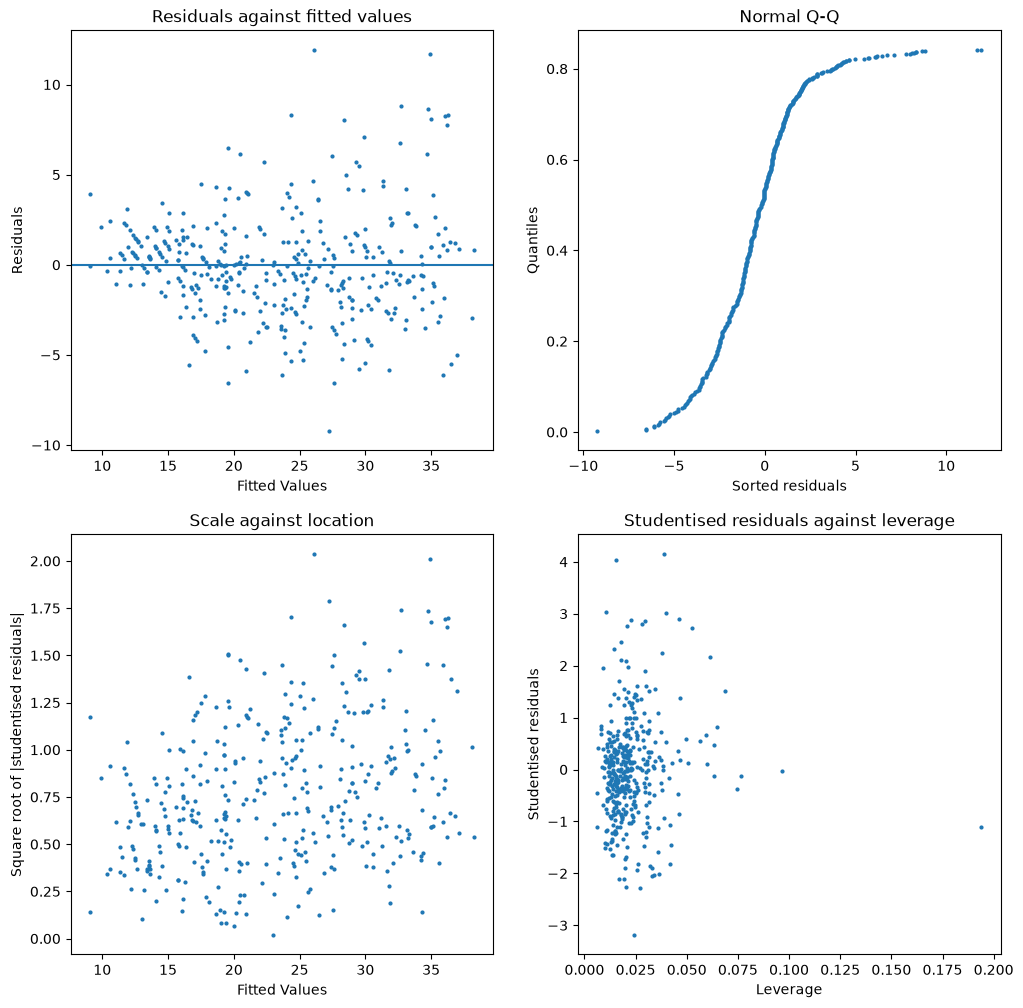

In [96]:
diagnostic_plots(linear_model_interactions)

**Part (f)**\
Try a few different transformations of the variables, such as $\text{log}(X), \sqrt{X}, X^2$.

In [97]:
X['horsepower2'] = X['horsepower'] ** 2
X['cylinders2'] = X['cylinders'] ** 2

linear_model_poly = sm.OLS(y, X).fit()
print(linear_model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     240.7
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          7.16e-158
Time:                        23:59:33   Log-Likelihood:                -971.12
No. Observations:                 392   AIC:                             1964.
Df Residuals:                     381   BIC:                             2008.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
cylinders                 -2

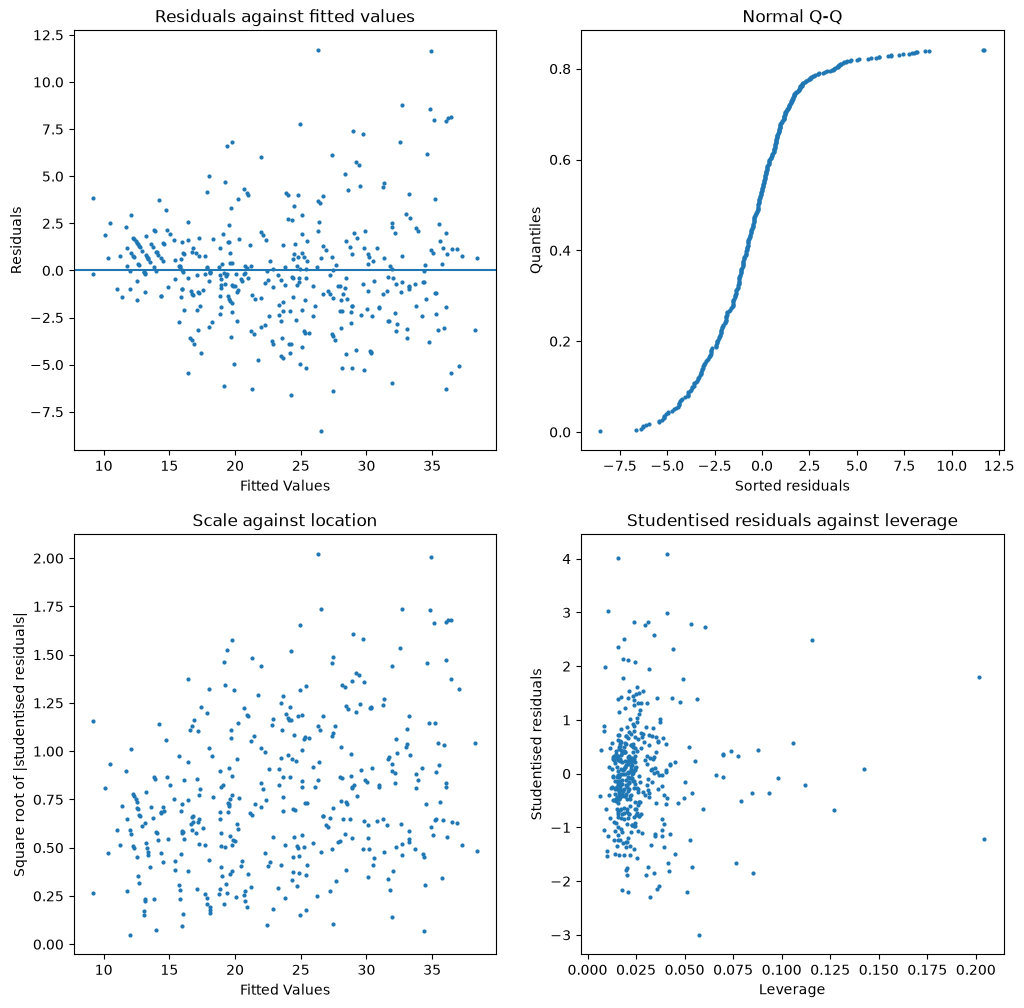

In [98]:
diagnostic_plots(linear_model_poly)